In [3]:
using Pkg, JuMP, Gurobi, Random, CPLEX, CSV, DataFrames, Plots

Pour le sous problème sans PL, tester d'abord si sum(y_i) = d
Gurobi n'a pas de Benders intégré (utiliser CPLEX sous Windows)

### Exercice 1

In [4]:
function loadData(n::Int, imp::Int=0; seed::Int=67)
    d = div(n,2)
    f = zeros(Int, n)
    c = zeros(Int, n)
    f[1] = 7
    c[1] = 8
    for i in 2:n
        f[i] = rem(f[i-1]*f[1], 159)
        c[i] = rem(c[i-1]*c[1], 61)
    end

    rng = MersenneTwister(seed)

    # Generate imp unique implications
    if imp == 0
        implications = [(1,2), (1,3)]
    else
        implications = Set{Tuple{Int,Int}}()
        while length(implications) < imp
            i, j = rand(rng, 1:n), rand(rng, 1:n)
            if i != j
                push!(implications, (i, j))
            end
        end
    end

    return n, d, f, c, collect(implications)
end

function loadBaseData()
    n = 5
    f = [7, 2, 2, 7, 7]
    c = [666, 5, 4, 3, 2]
    d = 2
    implications = [(1,2), (1,3)]
    return n, d, f, c, implications
end

function gen_n_values(start=1, ending=5, length=20)
    n_values = round.(Int, 10 .^ range(start, ending, length=length))
    n_values = [iseven(n) ? n : n + 1 for n in n_values]
    n_values = [n == 62 ? 64 : n for n in n_values]
    unique!(n_values)
    return n_values
end

function get_x_from_y(n::Int, d::Int, c::Vector{Int}, y_opt::Vector{})
    open_facilities = sort(findall(round.(y_opt) .== 1), by = i -> c[i])
    @assert length(open_facilities) >= d "Not enough open facilities ($( length(open_facilities))) to serve $d clients"
    x_opt = zeros(Int, n)
    x_opt[open_facilities[1:d]] .= 1
    return x_opt
end

get_x_from_y (generic function with 1 method)

In [5]:
function compactModel(n::Int, d::Int, f::Vector{Int64}, c::Vector{Int64}, implications::Vector{}, TimeLimit::Int=60)

    t0 = time_ns()

    mod = Model(CPLEX.Optimizer)   

    set_optimizer_attribute(mod, "CPXPARAM_ScreenOutput", 0)
    set_optimizer_attribute(mod, "CPXPARAM_TimeLimit", TimeLimit)
    set_optimizer_attribute(mod, "CPX_PARAM_EPGAP", 1e-6)

    @variable(mod, y[1:n], Bin)
    @variable(mod, x[1:n] >= 0)

    @constraint(mod, sum(x[i] for i in 1:n) == d)
    @constraint(mod, [i in 1:n], x[i] <= y[i])

    # Contraintes de design
    for (i, j) in implications
        @constraint(mod, y[i] >= y[j])
    end

    @objective(mod, Min, sum(f[i] * y[i] + c[i] * x[i] for i in 1:n))

    optimize!(mod)

    optimum = JuMP.objective_value(mod)
    lb = MOI.get(mod, MOI.ObjectiveBound())
    gap = MOI.get(mod, MOI.RelativeGap())
    solve_time = MOI.get(mod, MOI.SolveTimeSec())
    nodes = MOI.get(mod, MOI.NodeCount())
    y_opt = JuMP.value(y)
    x_opt = JuMP.value(x)

    println("Found an optimal solution of $optimum in $(round(solve_time, digits=3)) seconds and $nodes nodes")
    println("Opened $(sum(y_opt[i] for i in 1:n)) sites")

    elapsed = (time_ns() - t0) / 1e9

    return (optimum, y_opt, x_opt, elapsed)
end

compactModel (generic function with 2 methods)

In [6]:
function bendersAuto(n::Int, d::Int, f::Vector{Int64}, c::Vector{Int64}, implications::Vector{}, TimeLimit::Int=1000)

    t0 = time_ns()

    mod = Model(CPLEX.Optimizer)   

    set_optimizer_attribute(mod, "CPXPARAM_ScreenOutput", 0)
    set_optimizer_attribute(mod, "CPXPARAM_TimeLimit", TimeLimit)
    set_optimizer_attribute(mod, "CPXPARAM_Benders_Strategy", 3)
    set_optimizer_attribute(mod, "CPX_PARAM_EPGAP", 1e-6)

    @variable(mod, y[1:n], Bin)
    @variable(mod, x[1:n] >= 0)

    @constraint(mod, sum(x[i] for i in 1:n) == d)
    @constraint(mod, [i in 1:n], x[i] <= y[i])

    # Contraintes de design
    for (i, j) in implications
        @constraint(mod, y[i] >= y[j])
    end

    @objective(mod, Min, sum(f[i] * y[i] + c[i] * x[i] for i in 1:n))

    optimize!(mod)

    optimum = JuMP.objective_value(mod)
    lb = MOI.get(mod, MOI.ObjectiveBound())
    gap = MOI.get(mod, MOI.RelativeGap())
    solve_time = MOI.get(mod, MOI.SolveTimeSec())
    nodes = MOI.get(mod, MOI.NodeCount())
    y_opt = JuMP.value(y)
    x_opt = JuMP.value(x)

    println("Found an optimal solution of $optimum in $(round(solve_time, digits=3)) seconds and $nodes nodes")
    println("Opened $(sum(y_opt[i] for i in 1:n)) sites")

    elapsed = (time_ns() - t0) / 1e9

    return (optimum, y_opt, x_opt, elapsed)
end

bendersAuto (generic function with 2 methods)

In [7]:
function separation_PL(n::Int, d::Int, c::Vector{Int64}, y::Vector{}, TimeLimit::Int=120)

    println("Starting separation")

    mod = Model(CPLEX.Optimizer)

    set_optimizer_attribute(mod, "CPXPARAM_ScreenOutput", 0)
    set_optimizer_attribute(mod, "CPXPARAM_TimeLimit", TimeLimit)
    set_optimizer_attribute(mod, "CPX_PARAM_EPGAP", 1e-6)

    @variable(mod, v[1:n] >= 0)
    @variable(mod, b)

    @constraint(mod, [i in 1:n], b - v[i] <= c[i])

    @objective(mod, Max, d * b - sum(y[i] * v[i] for i in 1:n))

    optimize!(mod)

    println(termination_status(mod))

    optimum = JuMP.objective_value(mod) 
    v_opt = JuMP.value(v)
    b_opt = JuMP.value(b)

    return (optimum, v_opt, b_opt)

end

separation_PL (generic function with 2 methods)

In [8]:
function separation_speedy(n::Int, d::Int, c::Vector{Int64}, y::Vector{})

    b_opt = maximum(c[i] for i in 1:n)

    v_opt = zeros(n)
    for i in 1:n
        v_opt[i] = b_opt - c[i]
    end

    optimum = d * b_opt - sum(y[i] * v_opt[i] for i in 1:n)

    return (optimum, v_opt, b_opt)
end

separation_speedy (generic function with 1 method)

In [9]:
function main(n::Int, d::Int, f::Vector{Int}, c::Vector{Int}, B::Vector{}, V::Vector{}, implications::Vector{}, TimeLimit::Int=120)

    println("Starting main")
    
    mod = Model(CPLEX.Optimizer)

    set_optimizer_attribute(mod, "CPXPARAM_ScreenOutput", 0)
    set_optimizer_attribute(mod, "CPXPARAM_TimeLimit", TimeLimit)
    set_optimizer_attribute(mod, "CPX_PARAM_EPGAP", 1e-6)

    @variable(mod, y[1:n], Bin)
    @variable(mod, w >= 0)

    # Contraintes de design
    for (i, j) in implications
        @constraint(mod, y[i] >= y[j])
    end

    # Coupe de faisabilité
    @constraint(mod, sum(y[i] for i in 1:n) >= d)

    # Coupes d'optimalité
    @constraint(mod, [l in eachindex(B)], w >= d * B[l] - sum(y[i] * V[l][i] for i in 1:n))

    @objective(mod, Min, sum(f[i] * y[i] for i in 1:n) + w)

    optimize!(mod)

    optimum = JuMP.objective_value(mod)
    lb = MOI.get(mod, MOI.ObjectiveBound())
    gap = MOI.get(mod, MOI.RelativeGap())
    solve_time = MOI.get(mod, MOI.SolveTimeSec())
    nodes = MOI.get(mod, MOI.NodeCount())
    y_opt = JuMP.value(y)
    w_opt = JuMP.value(w)

    return (optimum, y_opt, w_opt)

end



main (generic function with 2 methods)

In [10]:
function benders(n::Int, d::Int, f::Vector{Int}, c::Vector{Int}, implications::Vector{}, speedy_sep::Bool=false, timeLimit::Int = 120)

    t0 = time_ns()
    
    # Initialize values
    optimum = 0
    y_opt = zeros(n)
    B = []
    V = []
    optimal = false
    
    while (!optimal) && ((time_ns() - t0) / 1e9 < timeLimit)

        optimal = true

        (optimum, y_opt, w_opt) = main(n, d, f, c, B, V, implications)

        if (speedy_sep) && (sum(y_opt[i] for i in 1:n) == d)
            println("Doing Speedy Sep, sum(y) = $(sum(y_opt[i] for i in 1:n))")
            (sep_optimum, v_opt, b_opt) = separation_speedy(n, d, c, y_opt)
        else
            println("Doing PL Sep, sum(y) = $(sum(y_opt[i] for i in 1:n))")
            (sep_optimum, v_opt, b_opt) = separation_PL(n, d, c, y_opt)
        end

        if (w_opt < sep_optimum - 1e-6)
            optimal = false
            push!(V, copy(v_opt))
            push!(B, copy(b_opt))
        end

    end

    println("L'optimum vaut $(optimum)")
    elapsed = (time_ns() - t0) / 1e9

    return (optimum, y_opt, elapsed)
end

benders (generic function with 3 methods)

In [11]:
function evaluate(method::Int=1, imp::Bool=false, n_values::Array{}=[10, 100, 1000, 10000, 100000])
    
    if imp
        filename = "results/results_$(method)_imp.csv"
    else
        filename = "results/results_$(method)_simple.csv"
    end

    open(filename, "w") do file
        # Header
        println(file, "n,optimum,elapsed")

        for n in n_values
            if imp
                (n, d, f, c, implications) = loadData(n,n)
            else
                (n, d, f, c, implications) = loadData(n,0)
            end

            if method == 1
                (optimum, y_opt, x_opt, elapsed) = compactModel(n, d, f, c, implications, 120)
            elseif method == 2
                (optimum, y_opt, elapsed) = benders(n, d, f, c, implications, false)
            elseif method == 3
                (optimum, y_opt, elapsed) = benders(n, d, f, c, implications, true)
            else
                (optimum, y_opt, x_opt, elapsed) = bendersAuto(n, d, f, c, implications)
            end

            println("optimum : $optimum, elapsed : $(round(elapsed, digits=3))")
            println(file, "$n,$optimum,$(round(elapsed, digits=3))")
        end
    end

    println("Results saved to $filename")
end

evaluate (generic function with 4 methods)

In [12]:
n_values=gen_n_values(1,5,20)

for i in 1:0
    evaluate(i, false, n_values)
end

n_values=gen_n_values(1,4.78,20)

for i in 4:4
    evaluate(i, true, n_values)
end

Found an optimal solution of 314.0 in 0.12 seconds and 0 nodes
Opened 5.0 sites
optimum : 314.0, elapsed : 3.559
Found an optimal solution of 556.0 in 0.016 seconds and 0 nodes
Opened 8.0 sites
optimum : 556.0, elapsed : 0.025
Found an optimal solution of 792.0 in 0.017 seconds and 0 nodes
Opened 13.0 sites
optimum : 792.0, elapsed : 0.019
Found an optimal solution of 1289.0 in 0.018 seconds and 0 nodes
Opened 20.0 sites
optimum : 1289.0, elapsed : 0.023
Found an optimal solution of 2213.0 in 0.017 seconds and 0 nodes
Opened 32.0 sites
optimum : 2213.0, elapsed : 0.019
Found an optimal solution of 3544.9999999999973 in 0.017 seconds and 0 nodes
Opened 49.999999999999886 sites
optimum : 3544.9999999999973, elapsed : 0.024
Found an optimal solution of 5697.0 in 0.035 seconds and 0 nodes
Opened 78.0 sites
optimum : 5697.0, elapsed : 0.037
Found an optimal solution of 8368.0 in 0.039 seconds and 0 nodes
Opened 124.0 sites
optimum : 8368.0, elapsed : 0.046
Found an optimal solution of 12942

In [52]:
function plot_elapsed_times(prefix::String, indices, imp="simple";
                            output::Union{Nothing,String}=nothing)

    dfs = DataFrame[]
    names = ["[FC]", "[FBPL]", "[FBEXP]", "[FBCPLEX]"]

    title = "\nTemps de résolution de l'instance de taille n"

    # Load all CSV files
    for i in indices
        filename = "$(prefix)_$(i)_$(imp).csv"
        df = CSV.read(filename, DataFrame)
        df[!, :instance] .= i
        push!(dfs, df)
    end

    data = vcat(dfs...)
    sort!(data, :n)

    # ---- Compute axis limits with margins ----
    xmin, xmax = extrema(data.n)
    ymin, ymax = extrema(data.elapsed)

    # Add multiplicative margins (important for log scale)
    xlims = (xmin * 0.9, xmax * 1.1)
    ylims = (ymin * 0.7, ymax * 1.5)

    # ---- Create plot with improved aesthetics ----
    plt = plot(
        xlabel = "Nombre de sites : n",
        ylabel = "Temps de résolution à l'optimum (s)",
        title = title,

        #xscale = :log10,
        #yscale = :log10,

        xlims = xlims,
        ylims = ylims,

        size = (1000, 700),              # bigger figure
        dpi = 300,                       # publication quality

        legend = :topleft,
        legendfontsize = 10,

        guidefontsize = 14,
        tickfontsize = 10,
        titlefontsize = 16,

        lw = 2,                          # thicker lines
        markersize = 5,

        grid = true,
        minorgrid = true,                # useful for log scale

        framestyle = :box,               # cleaner borders

        left_margin = 10Plots.mm,
        right_margin = 5Plots.mm,
        top_margin = 8Plots.mm,
        bottom_margin = 8Plots.mm
    )

    # ---- Plot each instance ----
    for i in indices
        subset = data[data.instance .== i, :]
        plot!(
            plt,
            subset.n,
            subset.elapsed,
            marker = :circle,
            label = names[i]
        )
    end

    # ---- Save if requested ----
    if output !== nothing
        savefig(plt, output)
    end

    return plt
end

plot_elapsed_times (generic function with 4 methods)

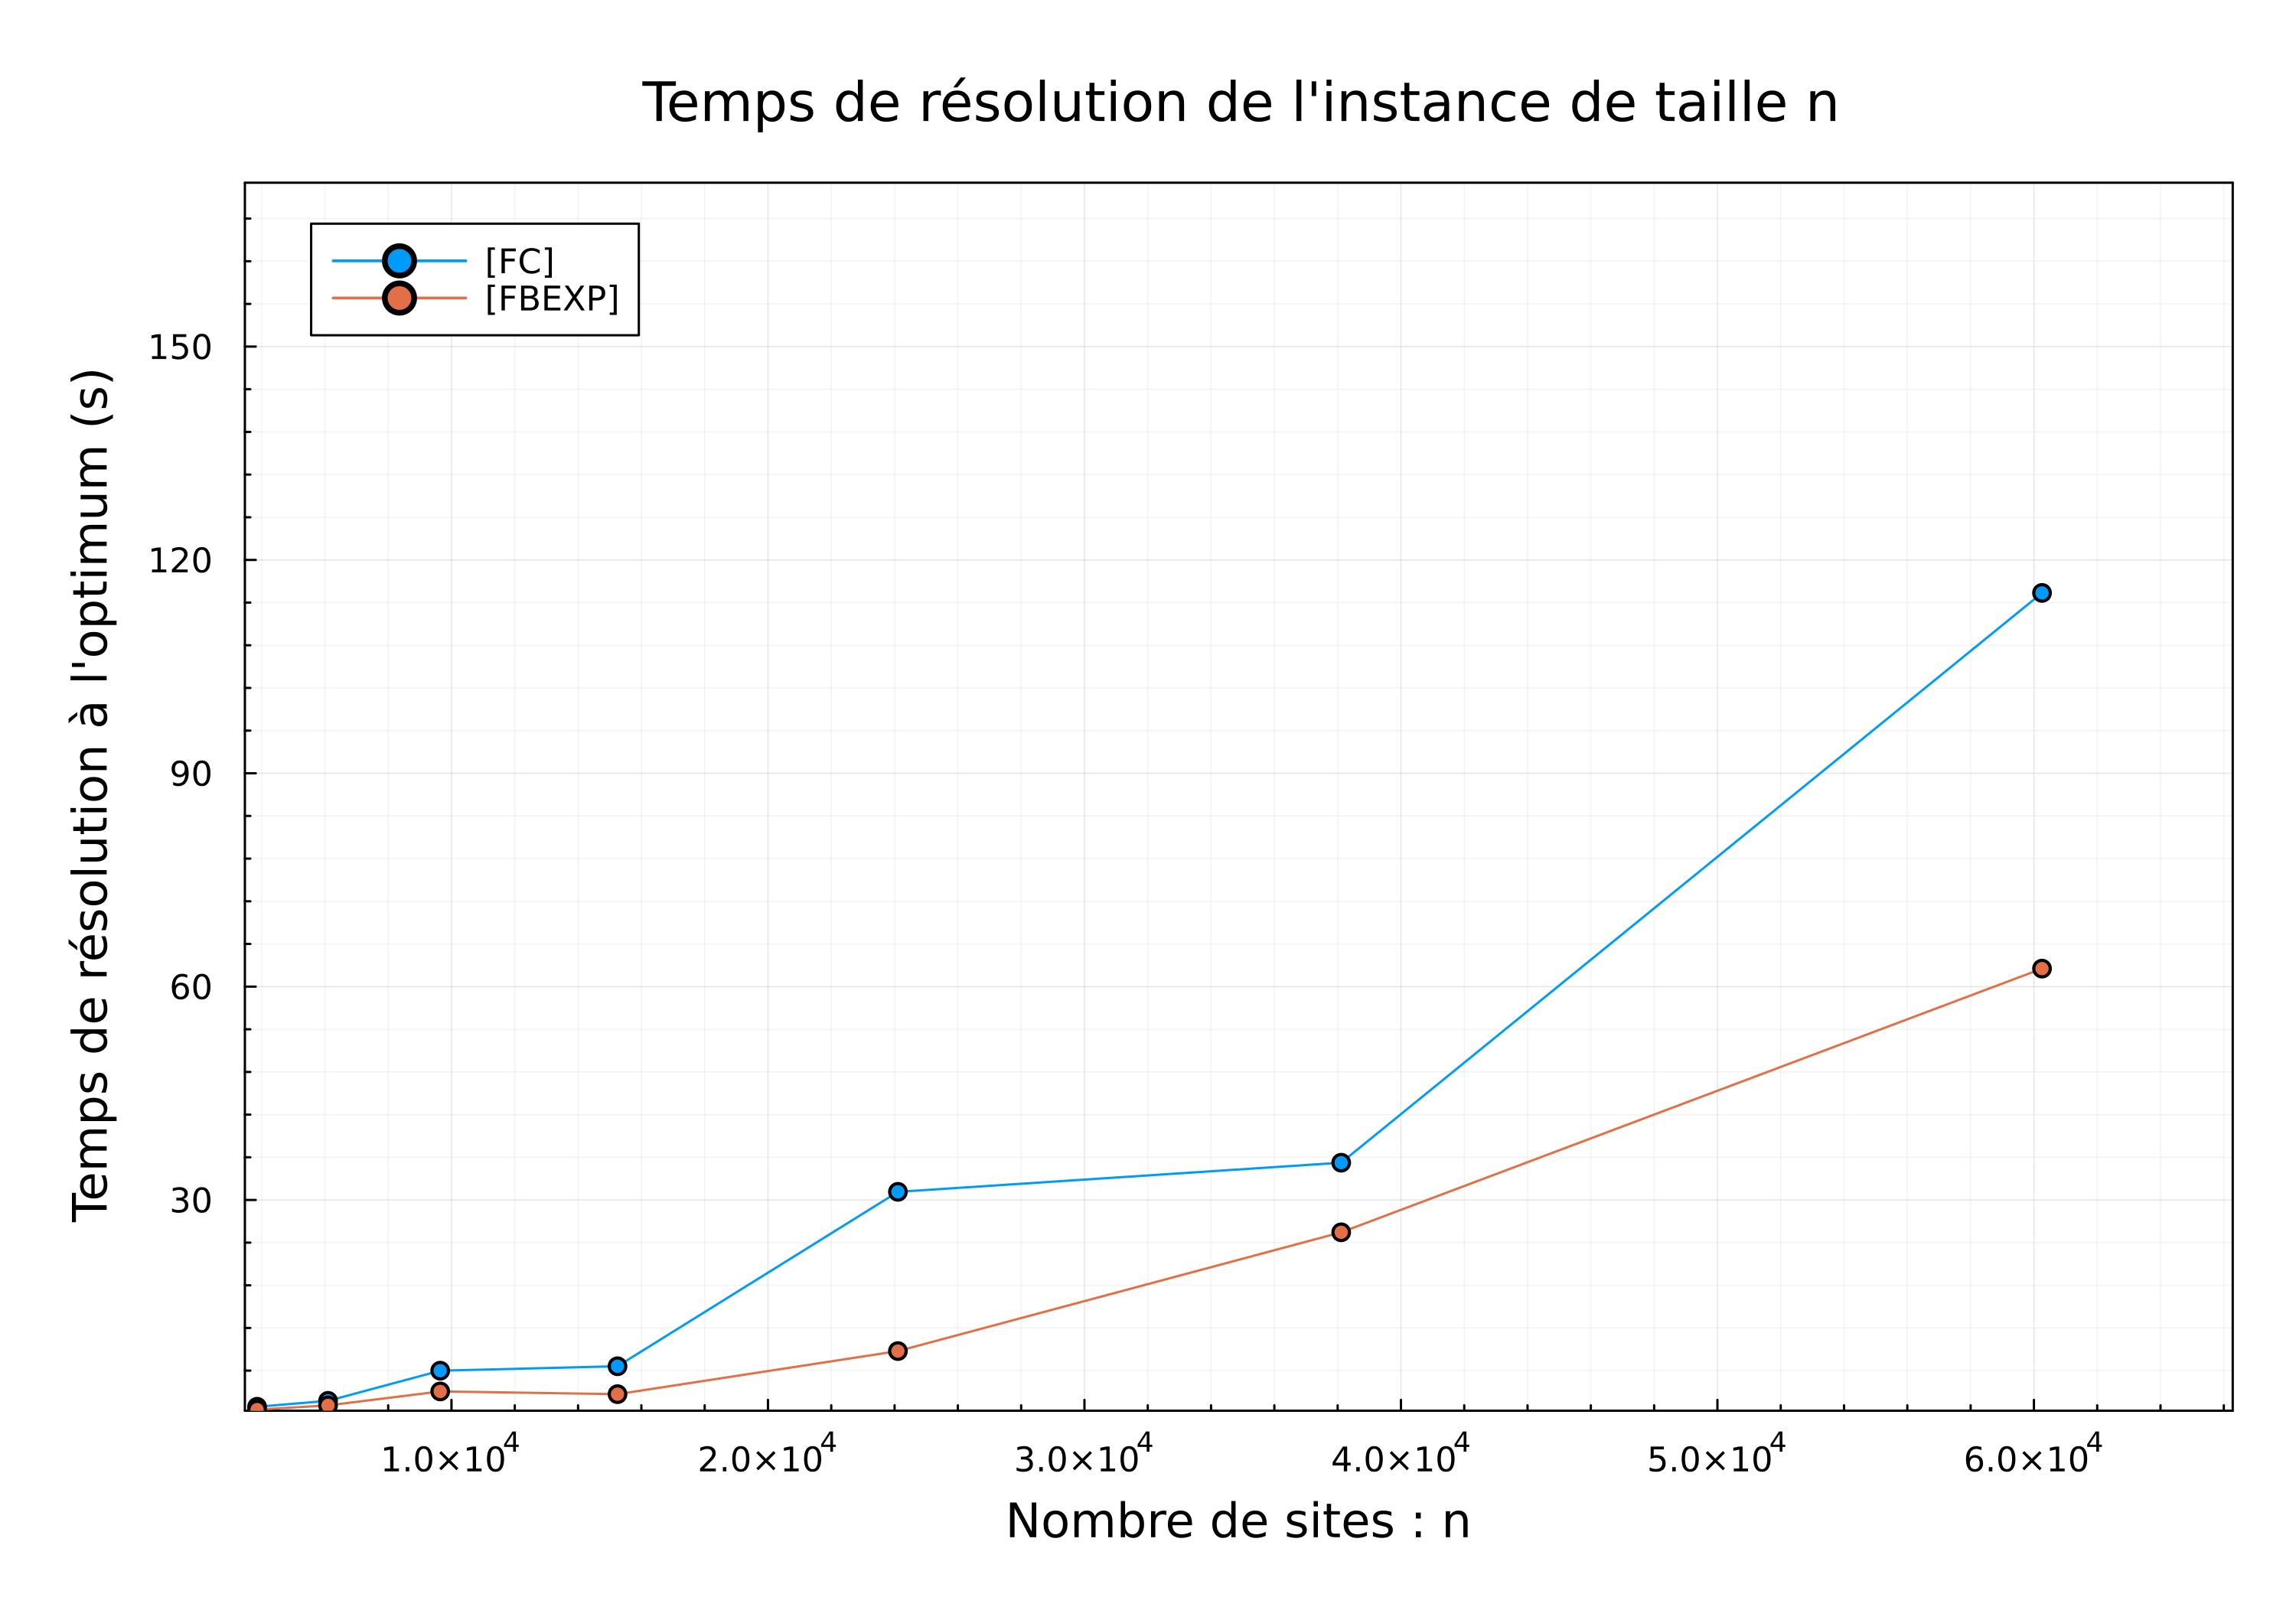

In [53]:
plot_elapsed_times("results/results", [1,3], "imp", output="plot_imp_13.png")

In [62]:
function export_latex_table(prefix, indices, imp="simple")
    dfs = [CSV.read("$(prefix)_$(i)_$(imp).csv", DataFrame) for i in indices]

    base = dfs[1][:, [:n, :optimum]]
    for (i, df) in enumerate(dfs)
        base[!, Symbol("solve_time$i")] = df.elapsed
    end

    println("\\begin{tabular}{rrrrrr}")
    println("\\toprule")
    println("\$n\$ & optimum & solve\\_time1 & solve\\_time2 & solve\\_time3 & solve\\_time4 \\\\")
    println("\\midrule")

    for row in eachrow(base)
        println("$(row.n) & $(round(row.optimum, digits=1)) & " *
                "$(row.solve_time1) & $(row.solve_time2) & $(row.solve_time3) & $(row.solve_time4) \\\\")
    end

    println("\\bottomrule")
    println("\\end{tabular}")
end

export_latex_table (generic function with 2 methods)

In [64]:
export_latex_table("results/results",1:4, "imp")

\begin{tabular}{rrrrrr}
\toprule
$n$ & optimum & solve\_time1 & solve\_time2 & solve\_time3 & solve\_time4 \\
\midrule
10 & 314.0 & 0.01 & 0.018 & 0.015 & 0.025 \\
16 & 556.0 & 0.01 & 0.018 & 0.015 & 0.025 \\
26 & 792.0 & 0.014 & 0.024 & 0.02 & 0.019 \\
40 & 1289.0 & 0.007 & 0.035 & 0.02 & 0.023 \\
64 & 2213.0 & 0.015 & 0.032 & 0.028 & 0.019 \\
100 & 3545.0 & 0.032 & 0.039 & 0.036 & 0.024 \\
156 & 5697.0 & 0.033 & 0.058 & 0.037 & 0.037 \\
248 & 8368.0 & 0.047 & 0.035 & 0.03 & 0.046 \\
390 & 12942.0 & 0.042 & 0.107 & 0.249 & 0.104 \\
618 & 20665.0 & 0.073 & 0.084 & 0.068 & 0.084 \\
976 & 33877.0 & 0.071 & 0.106 & 0.099 & 0.174 \\
1544 & 52890.0 & 0.176 & 0.283 & 0.307 & 0.64 \\
2440 & 82520.0 & 0.305 & 0.303 & 0.298 & 0.45 \\
3858 & 131330.0 & 0.92 & 0.633 & 0.516 & 1.069 \\
6100 & 210662.0 & 1.754 & 0.905 & 1.115 & 1.98 \\
9644 & 331551.0 & 5.992 & 2.886 & 3.076 & 6.094 \\
15246 & 522557.0 & 6.617 & 3.054 & 2.692 & 12.296 \\
24106 & 825502.0 & 31.143 & 9.639 & 8.751 & 76.958 \\
38112 &

In [13]:
n = 3858
(n, d, f, c, implications) = loadData(n,n)
(optimum1, y_opt1, x_opt1, elapsed1) = compactModel(n, d, f, c, implications, 120)
(optimum2, y_opt2, elapsed2) = benders(n, d, f, c, implications, false, 120)

x_opt2 = get_x_from_y(n, d, c, y_opt2)
cost2  = sum(f[i] * round(y_opt2[i]) + c[i] * x_opt2[i] for i in 1:n)

x_opt1 = get_x_from_y(n, d, c, y_opt1)
cost1  = sum(f[i] * round(y_opt1[i]) + c[i] * x_opt1[i] for i in 1:n)

for (i,j) in implications
    if (y_opt1[i] < y_opt1[j])
        println("$i,$j")
    end
end

Found an optimal solution of 131330.0 in 1.72 seconds and 0 nodes
Opened 1929.0 sites
Starting main
Doing PL Sep, sum(y) = 1929.0
Starting separation
OPTIMAL
Starting main
Doing PL Sep, sum(y) = 1929.0
Starting separation
OPTIMAL
L'optimum vaut 131330.0
